<a href="https://colab.research.google.com/github/HarshRaj3112007/100-Days-of-ML/blob/main/handle_missing_data2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('/content/titanic_toy.csv')

In [6]:
df.sample(10)

,Age,Fare,Family,Survived
630,80.0,30.0000,0,1
181,NaN,15.0500,0,0
200,28.0,9.5000,0,0
855,18.0,9.3500,1,1
256,NaN,79.2000,0,1
574,16.0,8.0500,0,0
495,NaN,14.4583,0,0
771,48.0,7.8542,0,0
557,NaN,227.5250,0,0
724,27.0,53.1000,1,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [8]:
df.isnull().sum()

,0
Age,177
Fare,45
Family,0
Survived,0


In [10]:
X = df.drop(columns = ['Survived'])
Y = df['Survived']

In [11]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2)

In [14]:
X_train

,Age,Fare,Family
51,21.00,7.8000,0
864,24.00,13.0000,0
305,0.92,NaN,3
631,51.00,7.0542,0
176,NaN,25.4667,4
...,...,...,...
871,47.00,NaN,2
410,NaN,7.8958,0
620,27.00,14.4542,1
21,34.00,13.0000,0


In [12]:
X_train.isnull().sum()

,0
Age,149
Fare,37
Family,0


In [15]:
x1 = X_train['Age'].mean()
x2 = X_train['Fare'].mean()
x3 = X_train['Age'].median()
x4 = X_train['Fare'].median()

In [16]:
X_train['Age_mean'] = X_train['Age'].fillna(x1)
X_train['Fare_mean'] = X_train['Fare'].fillna(x2)

In [17]:
X_train['Age_median'] = X_train['Age'].fillna(x3)
X_train['Fare_median'] = X_train['Fare'].fillna(x4)

In [18]:
X_train

,Age,Fare,Family,Age_mean,Fare_mean,Age_median,Fare_median
51,21.00,7.8000,0,21.000000,7.800000,21.00,7.8000
864,24.00,13.0000,0,24.000000,13.000000,24.00,13.0000
305,0.92,NaN,3,0.920000,32.305592,0.92,14.4542
631,51.00,7.0542,0,51.000000,7.054200,51.00,7.0542
176,NaN,25.4667,4,29.705009,25.466700,28.00,25.4667
...,...,...,...,...,...,...,...
871,47.00,NaN,2,47.000000,32.305592,47.00,14.4542
410,NaN,7.8958,0,29.705009,7.895800,28.00,7.8958
620,27.00,14.4542,1,27.000000,14.454200,27.00,14.4542
21,34.00,13.0000,0,34.000000,13.000000,34.00,13.0000


# Change of disribution


In [19]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  205.24727735757205
Age Variance after median imputation:  162.71656216438393
Age Variance after mean imputation:  162.2348380801064
Original Fare variable variance:  2473.898467416492
Fare Variance after median imputation:  2360.8800433384363
Fare Variance after mean imputation:  2345.158322136028


<Axes: xlabel='Age', ylabel='Density'>

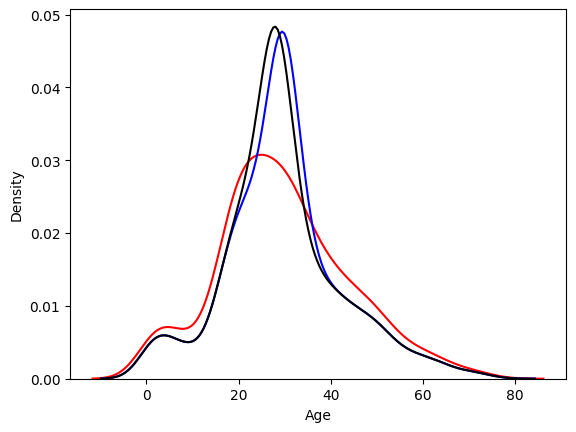

In [20]:
sns.kdeplot(X_train['Age'],color='r')
sns.kdeplot(X_train['Age_mean'],color='blue')
sns.kdeplot(X_train['Age_median'],color='black')


<Axes: xlabel='Fare', ylabel='Density'>

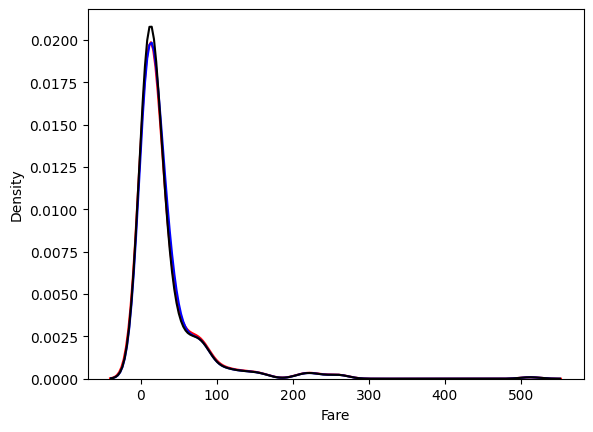

In [21]:
sns.kdeplot(X_train['Fare'],color='r')
sns.kdeplot(X_train['Fare_mean'],color='blue')
sns.kdeplot(X_train['Fare_median'],color='black')


In [23]:
X_train.cov()

,Age,Fare,Family,Age_mean,Fare_mean,Age_median,Fare_median
Age,205.247277,85.520335,-5.348959,205.247277,80.382341,205.247277,78.661056
Fare,85.520335,2473.898467,15.788681,67.025038,2473.898467,70.765626,2473.898467
Family,-5.348959,15.788681,2.450511,-4.228010,14.967048,-4.152326,15.077880
Age_mean,205.247277,67.025038,-4.228010,162.234838,63.537096,162.234838,62.176531
Fare_mean,80.382341,2473.898467,14.967048,63.537096,2345.158322,67.083026,2345.158322
Age_median,205.247277,70.765626,-4.152326,162.234838,67.083026,162.716562,65.605038
Fare_median,78.661056,2473.898467,15.077880,62.176531,2345.158322,65.605038,2360.880043


In [24]:
X_train.corr()

,Age,Fare,Family,Age_mean,Fare_mean,Age_median,Fare_median
Age,1.000000,0.111432,-0.256575,1.000000,0.108473,1.000000,0.105708
Fare,0.111432,1.000000,0.200142,0.105456,1.000000,0.111195,1.000000
Family,-0.256575,0.200142,1.000000,-0.212049,0.197434,-0.207944,0.198233
Age_mean,1.000000,0.105456,-0.212049,1.000000,0.103008,0.998519,0.100466
Fare_mean,0.108473,1.000000,0.197434,0.103008,1.000000,0.108595,0.996665
Age_median,1.000000,0.111195,-0.207944,0.998519,0.108595,1.000000,0.105848
Fare_median,0.105708,1.000000,0.198233,0.100466,0.996665,0.105848,1.000000


# Outlier Increment

<Axes: >

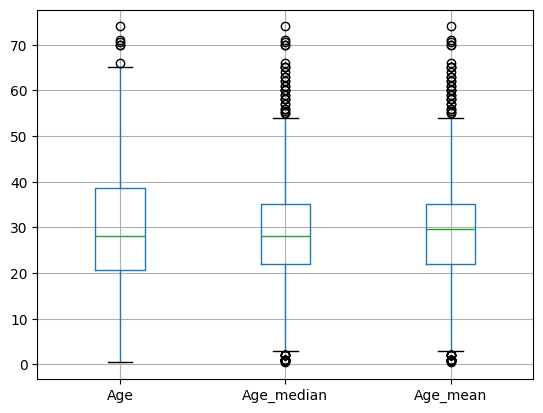

In [25]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

<Axes: >

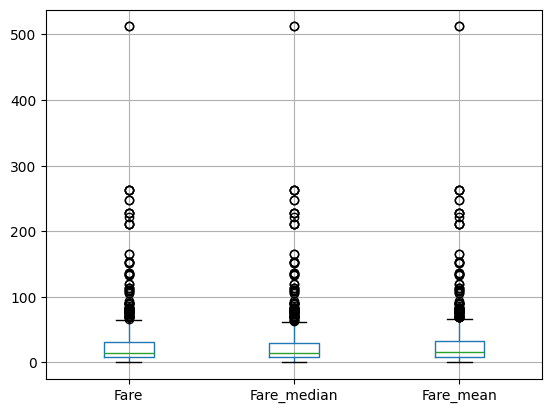

In [26]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

## Using sklearn now


In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [54]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [55]:
trf = ColumnTransformer([
    ('median_imputer',imputer1,['Age']),
    ('mean_imputer',imputer2,['Fare'])
],remainder='passthrough')

In [56]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('median_imputer',
                                 SimpleImputer(strategy='median'), ['Age']),
                                ('mean_imputer', SimpleImputer(), ['Fare'])])

In [57]:
trf.named_transformers_['median_imputer'].statistics_

array([28.75])

In [58]:
trf.named_transformers_['mean_imputer'].statistics_

array([32.61759689])

In [59]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [60]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])